In [ ]:
# Phase Zero

In [ ]:
# Understand CUAD completely before writing retrieval code.

In [ ]:
# SECTION  - Imports
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
# SECTION  - Dataset Paths

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'CUAD_v1.json' in files:
        print(root)

/content/drive/MyDrive/legal_ai/CUAD_v1


In [ ]:
from pathlib import Path

ROOT_DIR = Path("/content/drive/MyDrive/legal_ai/CUAD_v1")

JSON_PATH = ROOT_DIR / "CUAD_v1.json"

TXT_DIR = ROOT_DIR / "full_contract_txt"

PDF_DIR = ROOT_DIR / "full_contract_pdf"

CLAUSE_XLSX = ROOT_DIR / "master_clauses.csv"

In [ ]:
print("JSON:", JSON_PATH.exists())
print("TXT :", TXT_DIR.exists())
print("PDF :", PDF_DIR.exists())
print("XLSX:", CLAUSE_XLSX.exists())

JSON: True
TXT : True
PDF : True
XLSX: True


In [ ]:
# SECTION - Load CUAD JSON

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))

<class 'dict'>


In [ ]:
if isinstance(data, dict):
    print(data.keys())

elif isinstance(data, list):
    print("Records:", len(data))
    print(data[0].keys())

dict_keys(['version', 'data'])


In [ ]:
from pathlib import Path

txt_files = list(Path(TXT_DIR).rglob("*.txt"))

print("Total TXT Contracts:", len(txt_files))

Total TXT Contracts: 510


In [ ]:
sample_contract = txt_files[0]

print(sample_contract)

with open(sample_contract, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

print(text[:3000])

/content/drive/MyDrive/legal_ai/CUAD_v1/full_contract_txt/ADMA BioManufacturing, LLC -  Amendment #3 to Manufacturing Agreement .txt
Confidential treatment has been requested with respect to portions of this agreement as indicated by "[***]" and such confidential portions have been deleted and filed separately with the Securities and Exchange Commission pursuant to Rule 24b-2 of the Securities Exchange Act of 1934, as amended. Amendment #3 to the Manufacturing Agreement This Amendment #3 to the Manufacturing Agreement (this "Amendment #3") is made effective as of December 21, 2017 ("Amendment Effective Date"), by and between ADMA BioManufacturing, LLC, a Delaware limited liability company, having a place of business at 5800 Park of Commerce Boulevard NW, Boca Raton, Florida 33487 USA ("ADMA") and Sanofi Pasteur S.A., a company existing and organized under the laws of France ("Sanofi Pasteur"), having its registered head office at 14, espace Henry Vallee, 69007, Lyon, France. WHEREAS, A

In [ ]:
print(type(data["data"]))
print(len(data["data"]))

<class 'list'>
510


In [ ]:
data["data"][0].keys()

dict_keys(['title', 'paragraphs'])

In [ ]:
data["data"][0]

{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT',
 'paragraphs': [{'qas': [{'answers': [{'text': 'DISTRIBUTOR AGREEMENT',
       'answer_start': 44}],
     'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name',
     'question': 'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract',
     'is_impossible': False},
    {'answers': [{'text': 'Distributor', 'answer_start': 244},
      {'text': 'Electric City Corp.', 'answer_start': 148},
      {'text': 'Electric City of Illinois L.L.C.', 'answer_start': 49574},
      {'text': 'Company', 'answer_start': 197},
      {'text': 'Electric City of Illinois LLC', 'answer_start': 212}],
     'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Parties',
     'question': 'Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed t

In [ ]:
# Clause Taxonomy i.e. counting the clause categories
clause_counter = {}

for contract in data["data"]:

    for paragraph in contract["paragraphs"]:

        for qa in paragraph["qas"]:

            qid = qa["id"]

            clause_name = qid.split("__")[-1]

            clause_counter[clause_name] = clause_counter.get(clause_name, 0) + 1

print("Total Clause Types:", len(clause_counter))

Total Clause Types: 41


In [ ]:
sorted_clauses = sorted(
    clause_counter.items(),
    key=lambda x: x[1],
    reverse=True
)

sorted_clauses[:20]

[('Document Name', 510),
 ('Parties', 510),
 ('Agreement Date', 510),
 ('Effective Date', 510),
 ('Expiration Date', 510),
 ('Renewal Term', 510),
 ('Notice Period To Terminate Renewal', 510),
 ('Governing Law', 510),
 ('Most Favored Nation', 510),
 ('Non-Compete', 510),
 ('Exclusivity', 510),
 ('No-Solicit Of Customers', 510),
 ('Competitive Restriction Exception', 510),
 ('No-Solicit Of Employees', 510),
 ('Non-Disparagement', 510),
 ('Termination For Convenience', 510),
 ('Rofr/Rofo/Rofn', 510),
 ('Change Of Control', 510),
 ('Anti-Assignment', 510),
 ('Revenue/Profit Sharing', 510)]

In [ ]:
# Counting missing and present clauses (it will be used for the Risk Analysis)
present = 0
missing = 0

for contract in data["data"]:

    for paragraph in contract["paragraphs"]:

        for qa in paragraph["qas"]:

            if qa["is_impossible"]:
                missing += 1
            else:
                present += 1

print("Present Clauses:", present)
print("Missing Clauses:", missing)

Present Clauses: 6702
Missing Clauses: 14208


In [ ]:
# Building Clause Frequency Table
import pandas as pd

records = []

for contract in data["data"]:

    for paragraph in contract["paragraphs"]:

        for qa in paragraph["qas"]:

            records.append({
                "clause": qa["id"].split("__")[-1],
                "present": not qa["is_impossible"]
            })

df = pd.DataFrame(records)

df.head()

,clause,present
0,Document Name,True
1,Parties,True
2,Agreement Date,True
3,Effective Date,True
4,Expiration Date,True


In [ ]:
clause_stats = (
    df.groupby("clause")["present"]
      .sum()
      .sort_values(ascending=False)
)

clause_stats.head(20)

,present
clause,
Document Name,510
Parties,509
Agreement Date,470
Governing Law,437
Expiration Date,413
Effective Date,390
Anti-Assignment,374
Cap On Liability,275
License Grant,255


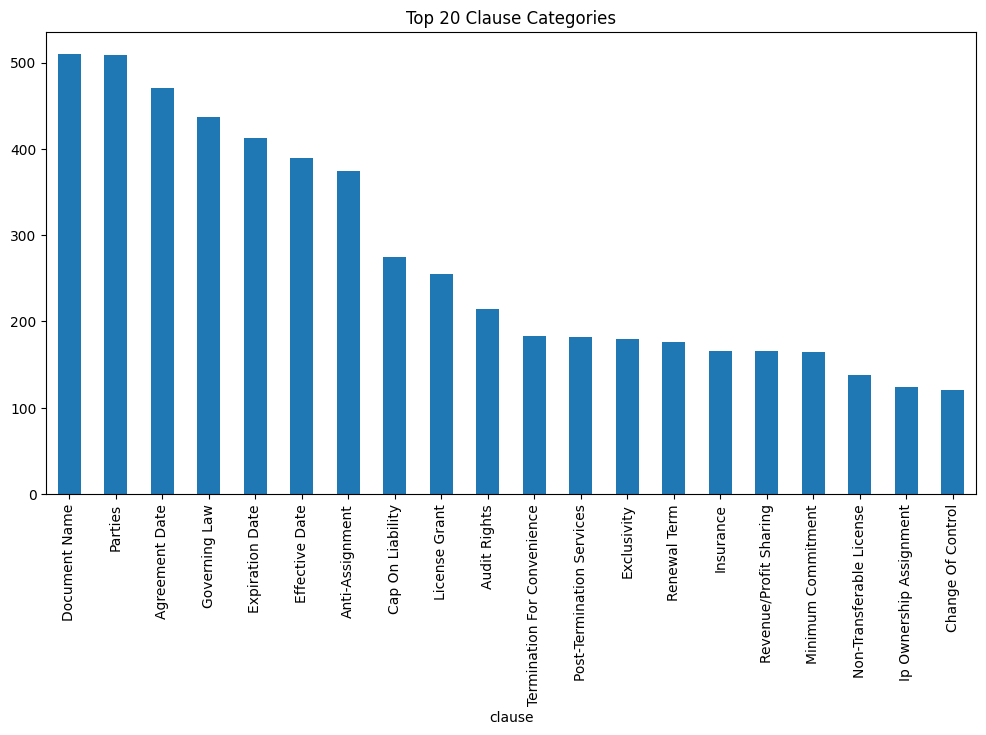

In [ ]:
import matplotlib.pyplot as plt

top20 = clause_stats.head(20)

plt.figure(figsize=(12,6))

top20.plot(kind="bar")

plt.title("Top 20 Clause Categories")

plt.show()

In [ ]:
#Inspect QA Structure
contract = data["data"][0]
paragraph = contract["paragraphs"][0]
qa = paragraph["qas"][0]
qa

{'answers': [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}],
 'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name',
 'question': 'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract',
 'is_impossible': False}

In [ ]:
qa.keys()

dict_keys(['answers', 'id', 'question', 'is_impossible'])

In [ ]:
qa["answers"] # our ground truth

[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]

In [ ]:
contract_clause_map = {}
for contract in data["data"]:

    contract_name = contract["title"]

    contract_clause_map[contract_name] = {}

    for paragraph in contract["paragraphs"]:

        for qa in paragraph["qas"]:

            clause = qa["id"].split("__")[-1]

            if not qa["is_impossible"]:

                answer_texts = [
                    ans["text"]
                    for ans in qa["answers"]
                ]

                contract_clause_map[
                    contract_name
                ][clause] = answer_texts

In [ ]:
first_contract = list(contract_clause_map.keys())[0]

print(first_contract)

contract_clause_map[first_contract]

LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT


{'Document Name': ['DISTRIBUTOR AGREEMENT'],
 'Parties': ['Distributor',
  'Electric City Corp.',
  'Electric City of Illinois L.L.C.',
  'Company',
  'Electric City of Illinois LLC'],
 'Agreement Date': ['7th day of September, 1999.'],
 'Effective Date': ['The term of this  Agreement  shall be ten (10)                            years (the "Term")  which shall  commence on the date                            upon which the Company  delivers to  Distributor  the                            last Sample, as defined  hereinafter.',
  'Unless  earlier   terminated   otherwise  provided                   therein,  this  Agreement,  subject to the  commencement  date                   established  in Section 1.3,  shall be effective  immediately.'],
 'Expiration Date': ['The term of this  Agreement  shall be ten (10)                            years (the "Term")  which shall  commence on the date                            upon which the Company  delivers to  Distributor  the                 

In [ ]:
# DATASET SUMMARY
print("="*50)
print("CUAD DATASET SUMMARY")
print("="*50)

print("Contracts:", len(data["data"]))
print("Clause Types:", len(clause_counter))
print("Present Clauses:", present)
print("Missing Clauses:", missing)

CUAD DATASET SUMMARY
Contracts: 510
Clause Types: 41
Present Clauses: 6702
Missing Clauses: 14208


In [ ]:
# 1. Inspect a QA object in detail
contract = data["data"][0]
paragraph = contract["paragraphs"][0]
qa = paragraph["qas"][0]

print("Question:", qa["question"])
print("Is impossible:", qa["is_impossible"])
print("Answers:", qa["answers"])
print("QA ID:", qa["id"])

Question: Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract
Is impossible: False
Answers: [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]
QA ID: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name


In [ ]:
# 2. Count QA pairs per contract
contract_stats = []

for contract in data["data"]:
    num_paragraphs = len(contract["paragraphs"])
    num_qas = sum(len(p["qas"]) for p in contract["paragraphs"])
    num_present = sum(
        1 for p in contract["paragraphs"] for qa in p["qas"] if not qa["is_impossible"]
    )
    num_missing = sum(
        1 for p in contract["paragraphs"] for qa in p["qas"] if qa["is_impossible"]
    )

    contract_stats.append({
        "title": contract["title"],
        "paragraphs": num_paragraphs,
        "qas": num_qas,
        "present": num_present,
        "missing": num_missing
    })

df_contract_stats = pd.DataFrame(contract_stats)
df_contract_stats.head()

,title,paragraphs,qas,present,missing
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,1,41,19,22
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",1,41,12,29
2,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_...,1,41,6,35
3,CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WE...,1,41,10,31
4,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,1,41,3,38


In [ ]:
# 3. Save summary
df_contract_stats.to_csv("/content/drive/MyDrive/legal_ai/cuad_contract_summary.csv", index=False)

In [ ]:
# 4. Load clause CSV
df_clauses = pd.read_csv(CLAUSE_XLSX)
print(df_clauses.head())
print(df_clauses.columns)

                                            Filename  \
0  CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...   
1  EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...   
2  FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...   
3  GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...   
4  IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...   

                                    Document Name  \
0               ['MARKETING AFFILIATE AGREEMENT']   
1   ['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT']   
2  ['CONTENT DISTRIBUTION AND LICENSE AGREEMENT']   
3           ['WEBSITE CONTENT LICENSE AGREEMENT']   
4                   ['CONTENT LICENSE AGREEMENT']   

                         Document Name-Answer  \
0               MARKETING AFFILIATE AGREEMENT   
1   VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT   
2  CONTENT DISTRIBUTION AND LICENSE AGREEMENT   
3           WEBSITE CONTENT LICENSE AGREEMENT   
4                   CONTENT LICENSE AGREEMENT   

                                             Part

In [ ]:
# Contract Metadata Table
contract_stats = []

for contract in data["data"]:

    contract_name = contract["title"]

    num_paragraphs = len(contract["paragraphs"])

    num_qas = 0
    num_present = 0
    num_missing = 0

    for paragraph in contract["paragraphs"]:

        num_qas += len(paragraph["qas"])

        for qa in paragraph["qas"]:

            if qa["is_impossible"]:
                num_missing += 1
            else:
                num_present += 1

    contract_stats.append({
        "contract_name": contract_name,
        "paragraphs": num_paragraphs,
        "qas": num_qas,
        "present_clauses": num_present,
        "missing_clauses": num_missing
    })

df_contract_stats = pd.DataFrame(contract_stats)

df_contract_stats.head()

,contract_name,paragraphs,qas,present_clauses,missing_clauses
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,1,41,19,22
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",1,41,12,29
2,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_...,1,41,6,35
3,CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WE...,1,41,10,31
4,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,1,41,3,38


In [ ]:
df_contract_stats.to_csv(
    "/content/drive/MyDrive/legal_ai/cuad_contract_summary.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [ ]:
clause_summary = pd.DataFrame(
    sorted_clauses,
    columns=["clause_type", "frequency"]
)

clause_summary.head()

,clause_type,frequency
0,Document Name,510
1,Parties,510
2,Agreement Date,510
3,Effective Date,510
4,Expiration Date,510


In [ ]:
clause_summary.to_csv(
    "/content/drive/MyDrive/legal_ai/cuad_clause_summary.csv",
    index=False
)

print("Clause Summary Saved")

Clause Summary Saved


In [ ]:
print("="*60)
print("CUAD DATASET EXPLORATION REPORT")
print("="*60)

print(f"Total Contracts           : {len(data['data'])}")
print(f"Total Clause Types        : {len(clause_counter)}")
print(f"Present Clauses           : {present}")
print(f"Missing Clauses           : {missing}")

print("\nTop 10 Clause Categories")

for clause, count in sorted_clauses[:10]:
    print(f"{clause:35s} {count}")

CUAD DATASET EXPLORATION REPORT
Total Contracts           : 510
Total Clause Types        : 41
Present Clauses           : 6702
Missing Clauses           : 14208

Top 10 Clause Categories
Document Name                       510
Parties                             510
Agreement Date                      510
Effective Date                      510
Expiration Date                     510
Renewal Term                        510
Notice Period To Terminate Renewal  510
Governing Law                       510
Most Favored Nation                 510
Non-Compete                         510


In [ ]:
sample_name = list(contract_clause_map.keys())[0]

print("="*60)
print("SAMPLE CONTRACT")
print("="*60)

print(sample_name)

print("\nAvailable Clauses:\n")

for clause in contract_clause_map[sample_name].keys():
    print(clause)

SAMPLE CONTRACT
LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT

Available Clauses:

Document Name
Parties
Agreement Date
Effective Date
Expiration Date
Renewal Term
Governing Law
Exclusivity
No-Solicit Of Customers
No-Solicit Of Employees
Rofr/Rofo/Rofn
Anti-Assignment
Price Restrictions
Minimum Commitment
License Grant
Post-Termination Services
Warranty Duration
Insurance
Covenant Not To Sue
